# **Parkinson’s Disease Detection From Vocal Metrics**

**Project Type : Healthcare / Classification**

**Project Prepared By : Pranav Thakur**

**Contribution : Individual**

# **Project Summary**

This project focuses on detecting Parkinson’s disease using vocal features such as frequency (Fo), jitter, shimmer, and HNR. The dataset contains biomedical voice measurements of individuals classified as either healthy or Parkinson-affected.

The workflow begins with data preprocessing and exploratory data analysis (EDA) to understand feature distributions and relationships. Key insights revealed that Parkinson patients tend to show higher jitter and shimmer (voice instability) and lower HNR (reduced voice clarity).

A machine learning model using an Artificial Neural Network (ANN) was built to classify individuals based on selected features. The model was trained on scaled data and evaluated using accuracy, confusion matrix, and classification metrics.

Finally, a Streamlit-based web application was developed where users can input voice parameters and get real-time predictions, making the model interactive and user-friendly.

# **Problem Statement**

Parkinson’s disease is a progressive neurological disorder that affects movement and speech. Early detection is crucial for timely treatment, but traditional diagnosis methods can be expensive and time-consuming.

The goal of this project is to build a predictive system that can detect Parkinson’s disease using easily measurable voice features such as frequency variations and signal noise characteristics.

The challenge is that individual features alone (like frequency) are not strong indicators, and there is overlap between healthy and Parkinson cases. Therefore, the task is to combine multiple features and build a model that can accurately classify patients.

# **1️⃣ Import Libraries**

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Deep Learning (ANN)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# **2️⃣ Dataset Loading**

In [ ]:
df = pd.read_csv("parkinsons.csv")
# Copy dataset
df_clean = df.copy()

# **Dataset First Look**

In [ ]:
print("First 5 Rows:\n")
df_clean.head()

First 5 Rows:



,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


# **Dataset Rows And Columns**

In [ ]:
print("Rows & Columns:",
df_clean.shape)

Rows & Columns: (195, 24)


# **Dataset Information**

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

# **Statistical Summary**

In [ ]:
df_clean.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


The dataset shows low average jitter and shimmer for most samples, but higher values in some cases indicate voice instability, which helps in detecting Parkinson’s disease

# Unique Values

In [ ]:
df_clean.nunique()

,0
name,195
MDVP:Fo(Hz),195
MDVP:Fhi(Hz),195
MDVP:Flo(Hz),195
MDVP:Jitter(%),173
MDVP:Jitter(Abs),19
MDVP:RAP,155
MDVP:PPQ,165
Jitter:DDP,180
MDVP:Shimmer,188


# **Duplicate Values**

In [ ]:
# Duplicate Rows
df.duplicated().sum()
df[df.duplicated()]

# Duplivate Columns
df.columns.duplicated().sum()

np.int64(0)

# **Missing Values**

In [ ]:
df_clean.isnull().sum()

,0
name,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),0
MDVP:Flo(Hz),0
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0


# **Data Wrangling**

In [ ]:
# Drop unnecessary column
if 'name' in df_clean.columns:
    df_clean = df_clean.drop(columns=['name'])

print(df_clean.head())

   MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  MDVP:Jitter(Abs)  \
0      119.992       157.302        74.997         0.00784           0.00007   
1      122.400       148.650       113.819         0.00968           0.00008   
2      116.682       131.111       111.555         0.01050           0.00009   
3      116.676       137.871       111.366         0.00997           0.00009   
4      116.014       141.781       110.655         0.01284           0.00011   

   MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  MDVP:Shimmer(dB)  ...  \
0   0.00370   0.00554     0.01109       0.04374             0.426  ...   
1   0.00465   0.00696     0.01394       0.06134             0.626  ...   
2   0.00544   0.00781     0.01633       0.05233             0.482  ...   
3   0.00502   0.00698     0.01505       0.05492             0.517  ...   
4   0.00655   0.00908     0.01966       0.06425             0.584  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       DFA   spread1  \
0

In [ ]:
# Separate features and target
X = df_clean.drop('status', axis=1)
y = df_clean['status']

In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# **Exploratory Data Analysis (EDA)**

# **1️⃣ Target Distribution**

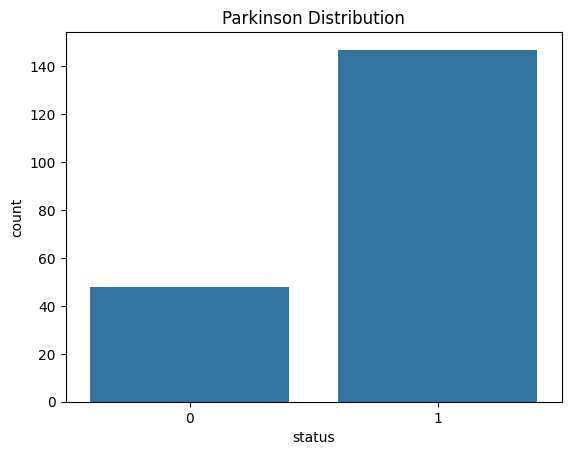

In [ ]:
sns.countplot(x='status', data=df_clean)
plt.title("Parkinson Distribution")
plt.show()

**Why this chart?**

To understand the balance between Parkinson and healthy cases.

**What does it show?**

Count of patients with Parkinson (1) and without Parkinson (0).

**Insight:**

The dataset is slightly imbalanced, with more Parkinson cases than healthy ones.

**Analysis:**

This imbalance may affect model performance, so evaluation metrics like precision and recall become important.

# **2️⃣ Feature Distribution**

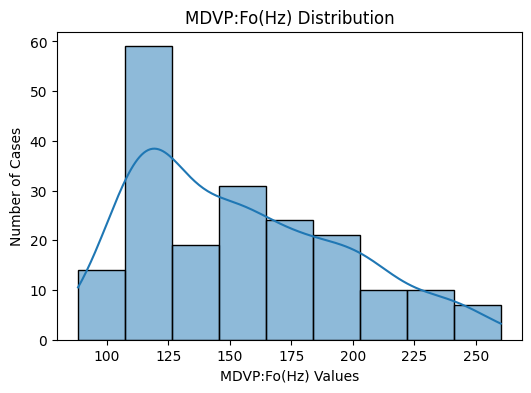

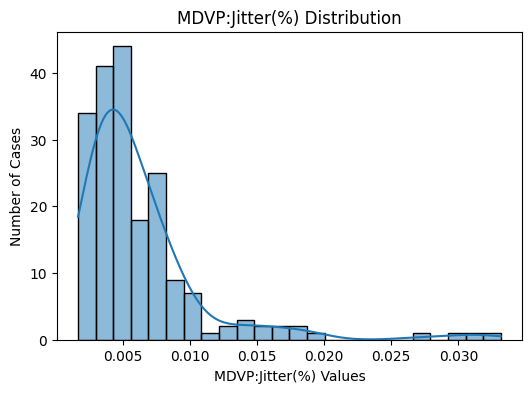

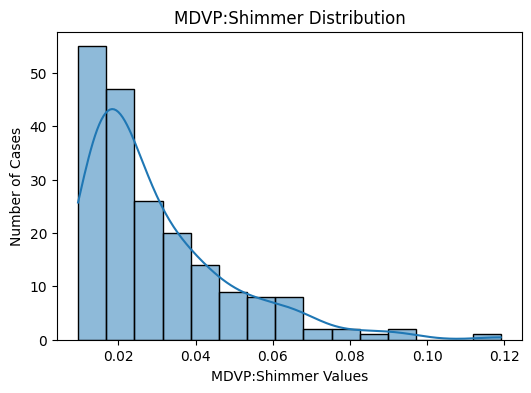

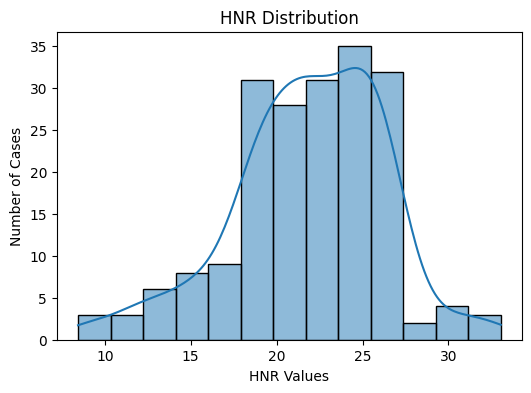

In [ ]:
features = ['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Shimmer', 'HNR']

for feature in features:
    plt.figure(figsize=(6,4))

    sns.histplot(df_clean[feature], kde=True)

    plt.title(f"{feature} Distribution")
    plt.xlabel(f"{feature} Values")
    plt.ylabel("Number of Cases")

    plt.show()

**Why this chart?**

To analyze how feature values are distributed.

**What does it show?**

Distribution of key features like Fo, Jitter, Shimmer, and HNR.

**Insight:**

Most features are right-skewed, with values concentrated at lower ranges.

**Analysis:**

Outliers and skewness indicate that normalization (scaling) is necessary for better model performance.

# **3️⃣ Jitter vs Parkinson**

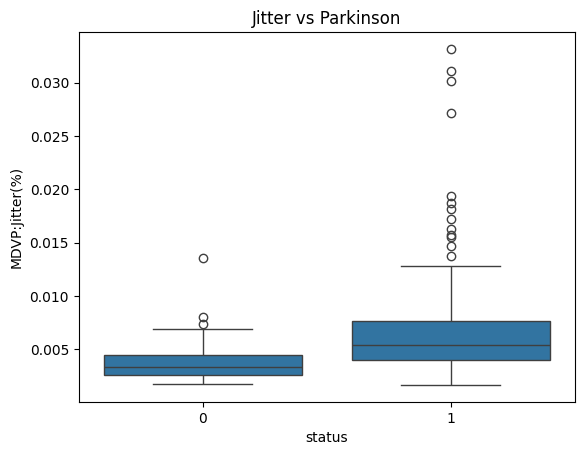

In [ ]:
sns.boxplot(x='status', y='MDVP:Jitter(%)', data=df_clean)
plt.title("Jitter vs Parkinson")
plt.show()

**Why this chart?**

To compare voice frequency variation between healthy and Parkinson patients.

**What does it show?**

Boxplot of jitter values across both classes.

**Insight:**

Parkinson patients tend to have higher jitter values.

**Analysis:**

Higher jitter reflects unstable vocal frequency, which is a strong indicator of Parkinson’s disease.

# **4️⃣ Shimmer vs Status**

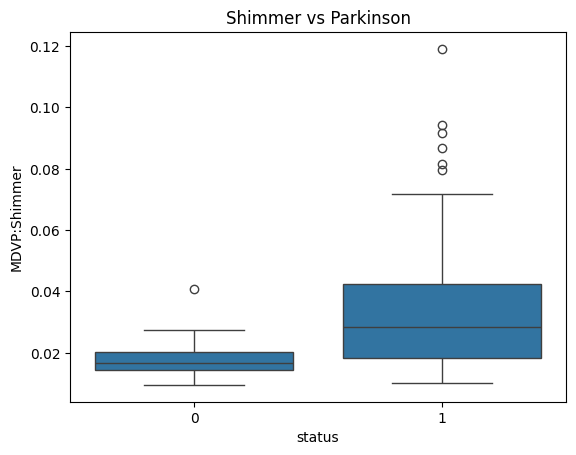

In [ ]:
sns.boxplot(x='status', y='MDVP:Shimmer', data=df_clean)
plt.title("Shimmer vs Parkinson")
plt.show()

**Why this chart?**

To analyze amplitude variation in voice.

**What does it show?**

Boxplot of shimmer values by status.

**Insight:**

Parkinson patients generally show higher shimmer values.

**Analysis:**

Increased shimmer indicates irregular vocal amplitude, which is common in Parkinson cases.

# **5️⃣ HNR vs Status**


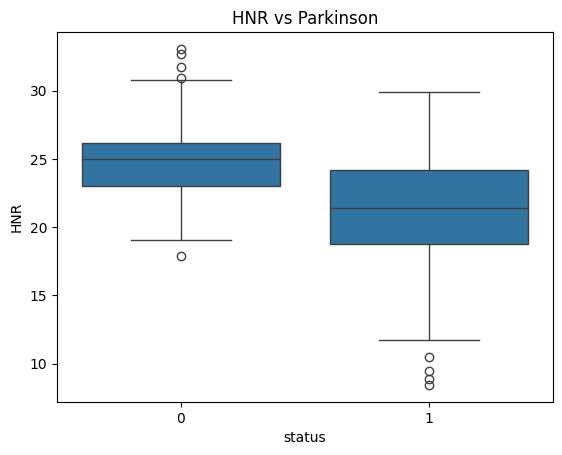

In [ ]:
sns.boxplot(x='status', y='HNR', data=df_clean)
plt.title("HNR vs Parkinson")
plt.show()

**Why this chart?**

To evaluate voice clarity and noise levels.

**What does it show?**

Boxplot of HNR values across classes.

**Insight:**

Healthy individuals have higher HNR, while Parkinson patients have lower values.

**Analysis:**

Lower HNR indicates more noise in voice signals, a key symptom of Parkinson’s disease.

# **6️⃣ MDVP:Fo vs Status**


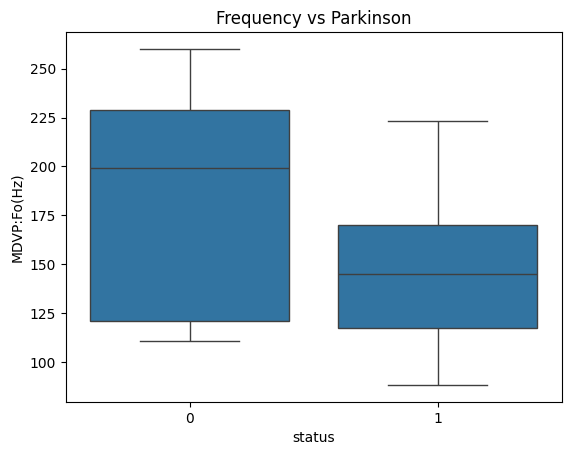

In [ ]:
sns.boxplot(x='status', y='MDVP:Fo(Hz)', data=df_clean)
plt.title("Frequency vs Parkinson")
plt.show()

**Why this chart?**

To compare pitch variations between groups.

**What does it show?**

Boxplot of fundamental frequency.

**Insight:**

No strong separation is observed between healthy and Parkinson groups.

**Analysis:**

Frequency alone is not a strong predictor, but it contributes when combined with other features.

# **7️⃣ Scatter Plot (Jitter & Shimmer)**

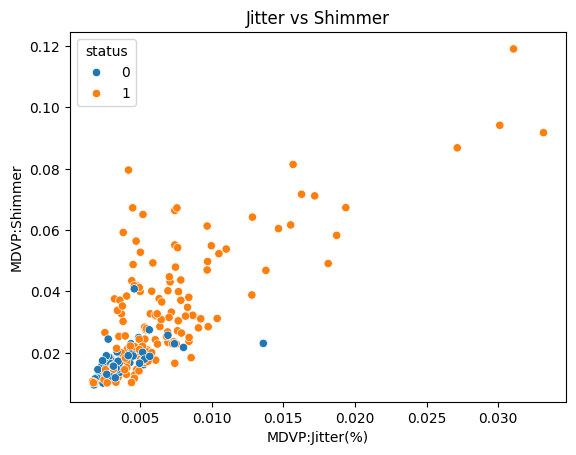

In [ ]:
sns.scatterplot(x='MDVP:Jitter(%)', y='MDVP:Shimmer', hue='status', data=df_clean)
plt.title("Jitter vs Shimmer")
plt.show()

**Why this chart?**

To analyze the relationship between jitter and shimmer and how they vary across healthy and Parkinson cases.

**What does it show?**

Scatter plot of jitter (x-axis) vs shimmer (y-axis), colored by disease status.

**Insight:**

Healthy patients are mostly clustered at lower jitter and shimmer values

Parkinson patients are spread toward higher values.

**Analysis:**

Higher jitter and shimmer indicate instability in voice frequency and amplitude.

Parkinson patients show more variability, which helps in distinguishing them from healthy individuals.

## **8️⃣ Fo vs HNR (Scatter Plot)**

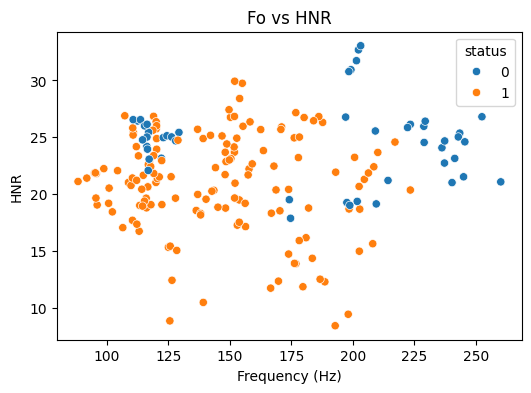

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=df_clean['MDVP:Fo(Hz)'],
    y=df_clean['HNR'],
    hue=df_clean['status']
)

plt.title("Fo vs HNR")
plt.xlabel("Frequency (Hz)")
plt.ylabel("HNR")

plt.show()

**Why this chart?**

To analyze the relationship between frequency (Fo) and voice clarity (HNR) and how they vary across healthy and Parkinson cases.

**What does it show?**

Scatter plot of Fo (x-axis) vs HNR (y-axis), colored by disease status.

# **Insight:**

Healthy individuals are generally observed at higher HNR values, indicating clearer voice signals.
Parkinson cases are more scattered and tend to have lower HNR values, showing reduced voice clarity.
However, there is a significant overlap between the two groups, especially in mid-range values.

**Analysis:**

Higher HNR reflects better voice quality, which is more common in healthy individuals.
Frequency (Fo) varies due to factors like age and gender, so it is not a strong standalone indicator.
The overlap between classes indicates that Fo and HNR alone cannot perfectly distinguish Parkinson cases, and multiple features are required for accurate prediction.

# **8️⃣ Correlation Heatmap**

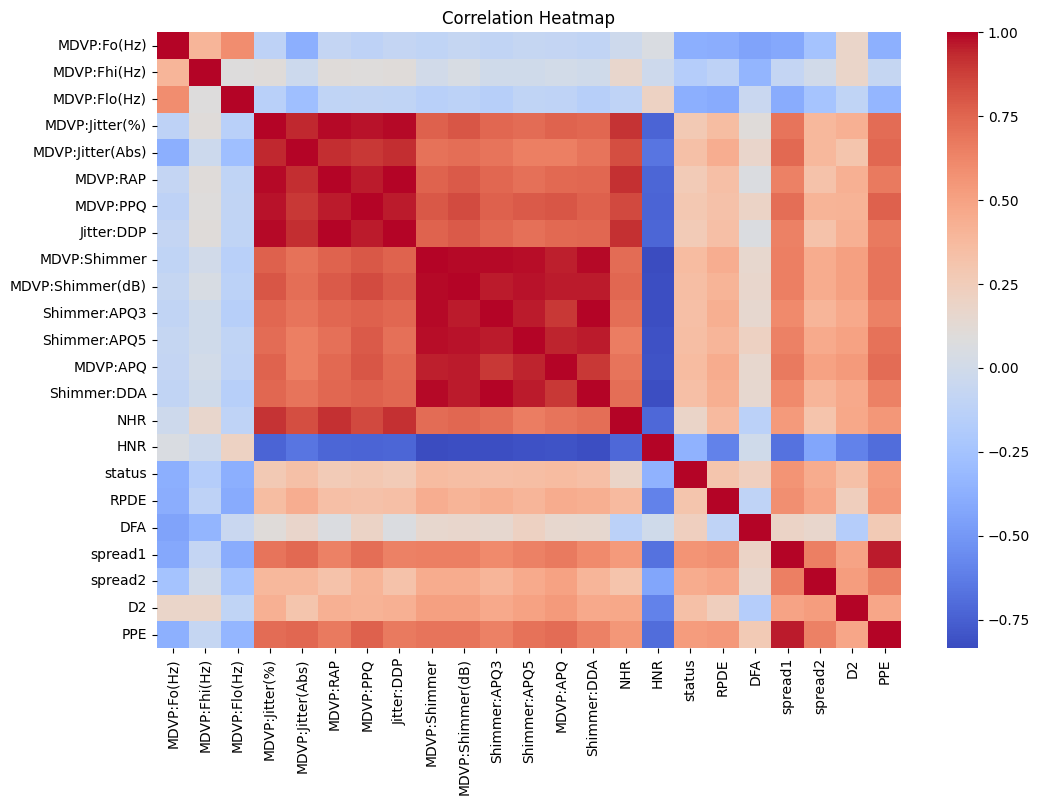

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Why this chart?**

To understand relationships between all features.

**What does it show?**

Correlation values between variables.

**Insight:**

Some features are highly correlated, especially jitter and shimmer-related features.

**Analysis:**

High correlation indicates redundancy, but also confirms that related features capture similar voice abnormalities.

# **Feature Selection**

In [ ]:
features = ['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Shimmer', 'HNR']

X = df_clean[features]
y = df_clean['status']


# **Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

import pickle
pickle.dump(scaler, open("scaler.pkl", "wb"))

# **Model Building (ANN - Artificial Neural Network)**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

# Input Layer
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer
model.add(Dense(32, activation='relu'))

# Dropout
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

# **Model Training**

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5806 - loss: 0.6747 - val_accuracy: 0.6250 - val_loss: 0.6283
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7500 - loss: 0.6024 - val_accuracy: 0.7188 - val_loss: 0.5614
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7903 - loss: 0.5571 - val_accuracy: 0.7812 - val_loss: 0.5214
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8226 - loss: 0.5181 - val_accuracy: 0.7812 - val_loss: 0.4915
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8145 - loss: 0.4877 - val_accuracy: 0.7812 - val_loss: 0.4706
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8145 - loss: 0.4693 - val_accuracy: 0.7500 - val_loss: 0.4544
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7984 - loss: 0.4539 - val_accuracy: 0.7500 - val_loss: 0.4416
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7903 - loss: 0.4278 - val_accuracy: 0.7500 - val_loss: 0.4333


# **Model Evaluation**

In [ ]:
# Predictions
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Accuracy: 0.7948717948717948

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.43      0.43         7
           1       0.88      0.88      0.88        32

    accuracy                           0.79        39
   macro avg       0.65      0.65      0.65        39
weighted avg       0.79      0.79      0.79        39



# **Model Performance Visualization**

# **Confusion Matrix**

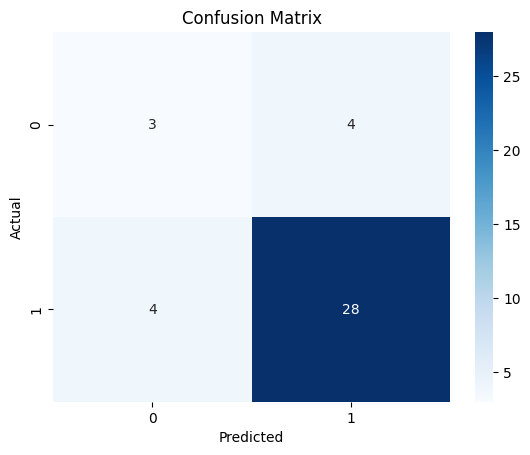

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Insights:**

* The model is mostly predicting correctly

* It can identify both healthy and Parkinson cases fairly well

* There are some misclassifications

**Overall :** The model is learning properly and not overfitting much

# **Accuracy Graph**

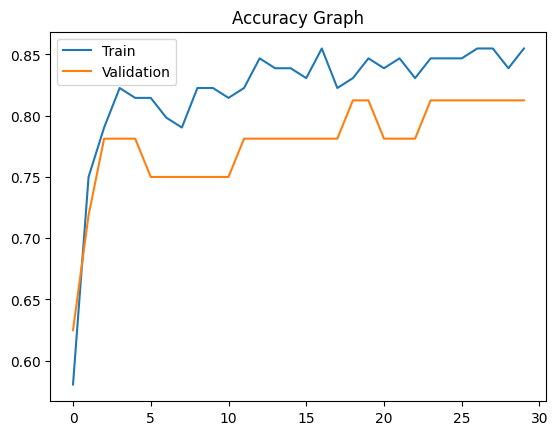

In [ ]:
# Accuracy Graph
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy Graph")
plt.legend()
plt.show()

**Insights :**

* Training accuracy is gradually increasing
* Validation accuracy is slightly lower but stable
* The gap between them is small

**Overall:** The model is learning properly and not overfitting much

# **Loss Graph**

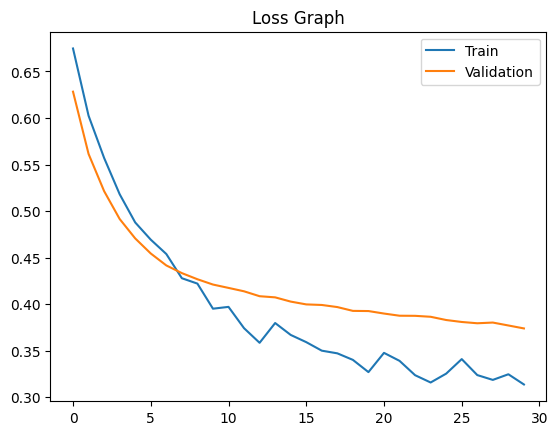

In [ ]:
# Loss Graph
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss Graph")
plt.legend()
plt.show()

Insights :
* Training loss is continuously decreasing
* Validation loss is also decreasing slowly
* No sudden spikes

**Overall:** the model is training smoothly and is stable

**Saving Model**

In [ ]:
model.save("ann_model.h5")

# **Streamlit Setup**

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 72.3 MB/s eta 0:00:00


# **Streamlit App Created**

In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle
from tensorflow.keras.models import load_model

# Load model & scaler
model = load_model("ann_model.h5")
scaler = pickle.load(open("scaler.pkl", "rb"))

# UI
st.set_page_config(page_title="Parkinson Detection", page_icon="🧠")
st.title("🧠 Parkinson Disease Detection")

col1, col2 = st.columns(2)

fo = col1.slider("Frequency (Fo Hz)", 80.0, 300.0, 120.0)
jitter = col1.slider("Jitter (%)", 0.0, 0.05, 0.005, step=0.001)

shimmer = col2.slider("Shimmer", 0.0, 0.1, 0.03, step=0.001)
hnr = col2.slider("HNR", 0.0, 40.0, 20.0, step=0.5)

if st.button("🔍 Predict"):
    data = scaler.transform([[fo, jitter, shimmer, hnr]])
    result = model.predict(data)[0][0]

    if result > 0.5:
        st.error("❌ Parkinson Detected")
    else:
        st.success("✅ Healthy")

Writing app.py


**App Run**

In [ ]:
!streamlit run app.py &>/dev/null &

**Generating Public URL**

In [ ]:
!pip install pyngrok

from pyngrok import ngrok
from google.colab import userdata

from pyngrok import ngrok

ngrok.kill()

# 🔑 Get token from secrets
NGROK_AUTH_TOKEN = userdata.get('cr_3CtbmNpj4PQBFWkdKnm0CW45JZI')

# set token
ngrok.set_auth_token("3CtbmNpj4PQBFWkdKnm0CW45JZI_2x6DwM4gbe13GsQxtzLPv")

# create tunnel
public_url = ngrok.connect(8501)

print("Your App URL:", public_url)

Your App URL: NgrokTunnel: "https://scrambler-illusive-sanded.ngrok-free.dev" -> "http://localhost:8501"


# **Final Conclusion**

The project successfully demonstrates that vocal features can be used to detect Parkinson’s disease with good accuracy.

Key findings include:

* Higher jitter and shimmer indicate unstable voice patterns, commonly seen in Parkinson patients
* Lower HNR reflects poor voice clarity, another strong indicator
* Frequency (Fo) alone is not a reliable predictor due to variations in age and gender

The ANN model showed stable performance with consistent training and validation accuracy, and no major overfitting was observed. The confusion matrix also confirms that the model is able to classify both healthy and Parkinson cases reasonably well, with only minor misclassifications.

The integration of the model into a Streamlit web app makes the solution practical and user-friendly, allowing real-time predictions based on user input.

 **Overall, this project proves that machine learning combined with voice analysis can be an effective and accessible approach for early Parkinson’s disease detection.**